in this cell i am importing all libraries needed for data work, plotting, and sklearn linear regression model training.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

here i load the tsla dataset and print first 3 rows of important columns just to confirm data is loaded correctly before preprocessing.

In [9]:
df = pd.read_csv("TSLA.csv")
print(df.head(3)[["Date", "Close(t)", "Volume", "MA5", "MA20", "RSI", "Close_forcast"]])

         Date  Close(t)    Volume      MA5      MA20        RSI  Close_forcast
0  2015-10-16    227.01   4334500  220.006  240.2085  41.229110         228.10
1  2015-10-19    228.10   2507900  222.510  238.4035  42.261535         213.03
2  2015-10-20    213.03  14900000  221.266  236.0080  33.499483         210.09


this part does feature engineering and train/validation split. i create return, moving average ratio, and log volume, then keep required columns, clean bad values, split 80/20, and create numpy arrays for modeling.

In [10]:
df = df.dropna().copy()
df["return_1d"] = (df["Close(t)"] / df["S_Close(t-1)"]) - 1
df["ma_ratio"] = df["MA5"] / df["MA20"]
df["vol_log"] = np.log1p(df["Volume"])

features = ["Close(t)", "return_1d", "ma_ratio", "vol_log", "RSI"]
target = "Close_forcast"

data = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

split = int(0.8 * len(data))
train = data.iloc[:split]
val = data.iloc[split:]

X_train = train[features].to_numpy()
y_train = train[target].to_numpy().reshape(-1, 1)
X_val = val[features].to_numpy()
y_val = val[target].to_numpy().reshape(-1, 1)

print("Train size:", X_train.shape[0], "Val size:", X_val.shape[0])

Train size: 972 Val size: 243


now i scale train and validation features using train mean and std. this helps linear regression stay stable and keeps feature magnitudes comparable.

In [11]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
X_train_norm = (X_train - mu) / sigma
X_val_norm = (X_val - mu) / sigma

print("First row after scaling:", X_train_norm[0])

First row after scaling: [-0.82420649  0.87654801 -1.56190826 -0.58067625 -0.744177  ]


in this cell i train sklearn linear regression, get `w` and `b`, make predictions on train/validation, and print the simple cost values for both.

In [ ]:
model = LinearRegression()
model.fit(X_train_norm, y_train)

w = model.coef_.reshape(-1, 1)
b = float(model.intercept_[0])

train_pred = model.predict(X_train_norm).reshape(-1, 1)
val_pred = model.predict(X_val_norm).reshape(-1, 1)

mse = mean_squared_error(y_val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_pred)

print("model trained")

MSE: 1756.568444900173
RMSE: 41.91143572940651
R2 score: 0.9884654281781095


this graph compares actual vs predicted values on validation data, so i can visually check if predictions are following the real trend.

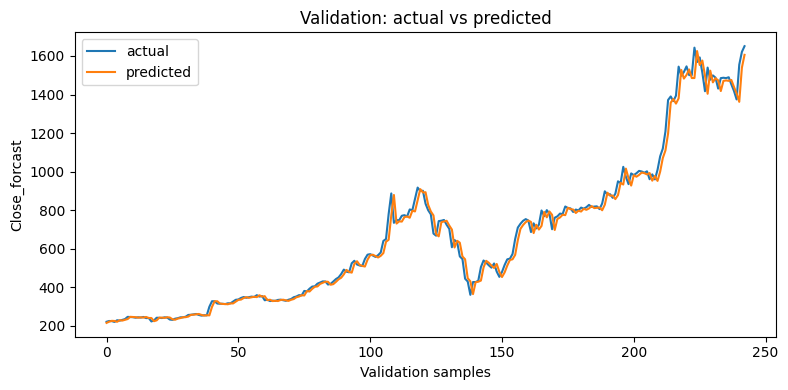

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(y_val.flatten(), label="actual")
plt.plot(val_pred.flatten(), label="predicted")
plt.xlabel("Validation samples")
plt.ylabel("Close_forcast")
plt.title("Validation: actual vs predicted")
plt.legend()
plt.tight_layout()
plt.show()

here i vary only `w1` while keeping other weights fixed, then compute cost each time to see how cost changes with that parameter.

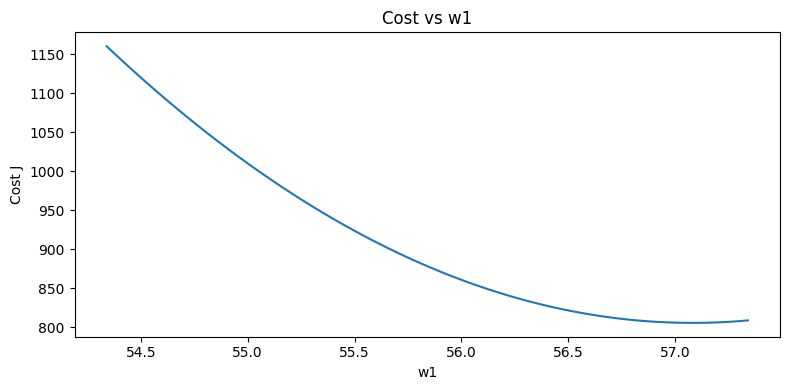

In [14]:
w1_values = np.linspace(w[0, 0] - 1.5, w[0, 0] + 1.5, 80)
J_values = []

for w1 in w1_values:
    w_try = w.copy()
    w_try[0, 0] = w1
    y_try = np.dot(X_val_norm, w_try) + b
    J_values.append(np.mean((y_try - y_val) ** 2) / 2)

plt.figure(figsize=(8, 4))
plt.plot(w1_values, J_values)
plt.xlabel("w1")
plt.ylabel("Cost J")
plt.title("Cost vs w1")
plt.tight_layout()
plt.show()

i am taking 3 metrics and pronting them

In [15]:
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 score:", r2)

MSE: 1756.568444900173
RMSE: 41.91143572940651
R2 score: 0.9884654281781095
